# Model analysis v5-BAFigs Nudging

March 1, 2023. Updated October 21, 2025.

Caroline Juang, c.juang@columbia.edu

This file makes analysis figures showing the effect of nudging the gSST 2 degrees northward, southward, eastward, and westward.

Models used:
* `Model_ENSOclim_Akaike` creates the SST-climate models, trained on SST data. Predicts climate data. Only run this when the observed data updates.
* `Model_Akaike` creates the climate-burned area models, trained on climate data. Predicts area burned. Only run this when the observd data updates.
* This final file is based on model runs: `Model_ENSOfull12-2022`, which intake the SST data and predicts burned area. Also included: climate observed vs. predicted, and burned area observed vs. model-predicted (both SST-climate-BA and climate-BA)

In [1]:
# import

from customscripts import *
from customconfig import *

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats.mstats import theilslopes
import scipy
import joblib
import datetime
from itertools import compress

# formatting shapefiles
from matplotlib.patches import Rectangle
from shapely.geometry import Polygon
from shapely.geometry import JOIN_STYLE
from shapely.ops import unary_union

# mapping
import geopandas as gpd
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, OCEAN, LAND, COASTLINE
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
#states = NaturalEarthFeature(category='cultural', scale='50m', facecolor='none',
#                             name='admin_1_states_provinces_shp')

# set figures formatting
import matplotlib
import matplotlib.colors as mcolors
from matplotlib import rc
import matplotlib.gridspec as gridspec
from matplotlib.colorbar import Colorbar
from matplotlib.ticker import FuncFormatter
import colorcet # more colormaps

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
plt.rcParams['figure.dpi'] = 200

In [2]:
# suppress deprecation warnings (temporarily using this bc matplotlib warnings)
import warnings
def fxn():
    warnings.warn("deprecated", DeprecationWarning)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    fxn()

In [3]:
### manual variables to change

# importing data string

# Read the climate index from the .txt file
with open('0_climindname.txt', 'r') as f:
    climindnameObs = f.read().strip()
print(climindnameObs +' will be used for the SST gradient')
climindnameDT = 'DeTrend_'+climindnameObs
climfilename = 'DeTrendClimObs_'+climindnameObs # same as Model_ENSOfull
#data_string = 'data\\'
data_string = 'data//'
#model_string = 'model\\'+climindnameObs+'\\'
model_string = 'model//'+climindnameObs+'//'
#predict_string = 'predicted\\'+climindnameObs+'\\'
predict_string = 'predicted//'+climindnameObs+'//'

# folder for saving figures
figfolder = 'your_figures_folder'

# data manipulation
years = np.arange(firstyear, finalyear+1)
# translate years into dates
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

# color palette for SST gradient
#colorobs = '#E2725B' # a warm red to denote warming
colorobs = '#fc8d62' # light orange, from colorbrewer2
#colorDT = '#9BC6F0' # blue color for neutral cool
#colorDT = '#3366CC' # darker blue color?
colorDT = '#8da0cb' # periwinkle blue, from colorbrewer2

patch125-155_nino3-34 will be used for the SST gradient


In [4]:
# skip analysis for these ecoprovinces for low fire occurrence
# create filter for westUS + ecoprovs
df_filter = np.ones(len(dfnames))
dfnames_filter = ['ecoprov3', 'ecoprov6', 'ecoprov18']
for thisname in dfnames_filter:
    df_filter[dfnames.index(thisname)] = 0 # filter out this ecoregion
# filter arrays
dfnames = list(compress(dfnames, df_filter))

# create filter for ecoprovs
df_filternum = np.ones(len(province_num))
province_num_filter = np.array([3,6,18])
for thisnum in province_num_filter:
    df_filternum[province_num==thisnum] = 0 # filter out this ecoregion
# filter arrays
province_names = list(compress(province_names, df_filternum))
prov_abbr_names = list(compress(prov_abbr_names, df_filternum))
province_num = np.array(list(compress(province_num, df_filternum)))

# Import data
from `data\Data_CreateModelData`

## for SST gradient, on map and then annual data
* `sstannual` is xarray gridded data of X,Y,and time=yearly SST globally
* `sstmonthly_df` is pandas dataframe of the SST gradient (west minus east) in degrees C on monthly scale
* `sstmonthly_DT_df` is pandas dataframe of the SST gradient, monthly scale, but detrended (zero slope)

In [5]:
# for getting annual trend of SST data
# import sst data
firstssttime = str((firstyear-2))+'-01-01'
#sst = xr.open_dataset(directory + 'NOAA_SST\\sst.mnmean.nc', engine='netcdf4')
sst = xr.open_dataset(directory + 'NOAA_SST//sst.mnmean.nc', engine='netcdf4')
sst = sst.sst.loc[firstssttime:finaltime]

# sample by year
sstannual = sst.resample(time='Y').mean()
del sst # free up space

In [6]:
# IMPORT SST GRADIENTS
# import observed SST gradient monthly, 1992-present
filename = data_string + 'gradient_'+climindnameObs+'.txt'
sstmonthly = pd.read_csv(filename).set_index('Unnamed: 0')
# import detrended SST gradient monthly
#filename = 'data\\gradient_'+climindnameDT+'.txt'
filename = data_string + 'gradient_'+climindnameDT+'.txt'
sstmonthly_DT = pd.read_csv(filename).set_index('Unnamed: 0')

# crop files
sstmonthly = sstmonthly.loc[firstyear-2:finalyear]
sstmonthly_DT = sstmonthly_DT.loc[firstyear-2:finalyear]
ssttime = pd.to_datetime(pd.date_range(start=str(sstmonthly.index[0])+'-01-01', end=finaltime, freq='M'), unit='M')

# create pd dataframe
sstmonthly_df = pd.DataFrame(data={'time': ssttime, 'anomaly': sstmonthly.to_numpy().flatten()}).set_index('time')
sstmonthly_DT_df = pd.DataFrame(data={'time': ssttime, 'anomaly': sstmonthly_DT.to_numpy().flatten()}).set_index('time')

## for Ecoprovince map

* `Becoprov` to plot shapefiles of Bailey's Ecoprovinces on a map so they can be colored according to data.
    * The CRS used is defined within the shapefile, so **no need to call `transform` when plotting**
* `ecoreg` to plot xarray-based gridded data of Bailey's ecoprovinces on a figure.
    * Use CRS `ccrs.PlateCarree()` when plotting

In [7]:
# import Bailey's Ecoregions
Bailey_string = '1km//landcover//ecoregions//shapefiles//bailey//eco-us-shp-GCS//eco-us-shp-GCS.shp'
Becoreg = gpd.read_file(directory + Bailey_string)

# projection info from file
Bailey_crs = Becoreg.crs

# get shapefile of just western US from US Census Bureau
# for some reason it includes Hawaii and Alaska
Census_string = 'Census Bureau//Cartographic Boundary Files_Regions//cb_2018_us_region_500k.shp'
wUSregion = gpd.read_file(directory + Census_string)
wUSregion = wUSregion[wUSregion.NAME=='West']
# remove HI and AK
extentpoly = Polygon([(-130,30), (-130,50), (-100,50),(-100,30)])
poly_gdf = gpd.GeoDataFrame(geometry=[extentpoly], crs=ccrs.PlateCarree())
wUSregion = wUSregion.clip(extentpoly)

wUSregion = wUSregion.to_crs(Bailey_crs) # transform projection

# clip the ecoregions to just western US
Becoreg = gpd.clip(Becoreg, wUSregion)
# sort to the same order as data
Becoreg = Becoreg.set_index('PROVINCE')
Becoreg = Becoreg.loc[province_names]

# iterate through ecoregions and merge into ecoprovinces
# group the data by ecoregion
Becoprov = gpd.GeoDataFrame(columns=['PROVINCE','NUMBER','geometry'], geometry='geometry')
gbecoreg = Becoreg.groupby('PROVINCE')
i = 0 # start counter
eps = 0.001 # define buffer
# iterate through each province and MERGE the ecoregions
for thisname, thisgroup in gbecoreg:
    thisgeometry = thisgroup.geometry.to_crs('epsg:5070') # set CRS with m as unit
    thisgeometry = thisgeometry.buffer(eps, 1, join_style=JOIN_STYLE.mitre) # add buffer
    thisgeometry = unary_union(thisgeometry).buffer(-eps, 1, join_style=JOIN_STYLE.mitre) # merge, then remove buffer
    thisgeometry = gpd.GeoSeries(thisgeometry).set_crs('epsg:5070').to_crs('epsg:4326') # set CRS with degrees
    #thisgeometry = gpd.GeoSeries(unary_union(thisgroup.geometry))
    thisprovince = gpd.GeoDataFrame(data={'PROVINCE': thisname, 
                                          'NUMBER': province_num[i], 
                                          'geometry': thisgeometry}, geometry='geometry')
    # append to create ecoprovince geodataframe
    Becoprov = gpd.GeoDataFrame(pd.concat([Becoprov, thisprovince], ignore_index=True))
    i+=1

# Becoprov is now a geodataframe I can use, with SHAPEFILES of provinces.

## import ecoprovinces xarray (gridded version)

In [8]:
ecoreg_string = directory + '12km//landcover//Ecoregions_EPA//bailey_ecoprovince.nc'
ecoreg = xr.open_dataset(ecoreg_string, engine='netcdf4')
print(ecoreg.bailey_ecoprovince.province.legend)
ecoreg = ecoreg.bailey_ecoprovince

# add in entire western US
#ecoreg = xr.concat([westUS, ecoreg.bailey_ecoprovince], dim='province')
# remove the ecoregion that does not overlap with the western US
ecoreg = ecoreg.sel(province=province_num[1:])

1: American Semi-Desert and Desert Province, 2: Arizona-New Mexico Mountains Semi-Desert-Open Woodland-Coniferous Forest-Alpine Meadow Province, 3: Black Hills Coniferous Forest Province, 4: California Coastal Chapparral Forest and Shrub Province, 5: California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow Province, 6: California Coastal Steppe-Mixed Forest-Redwood Forest Province, 7: California Dry Steppe Province, 8: Cascade Mixed Forest-Coniferous Forest-Alpine Meadow Province, 9: Chihuahuan Semi-Desert Province, 10: Colorado Plateau Semi-Desert Province, 11: Great Plains Steppe Province, 12: Great Plains-Palouse Dry Steppe Province, 13: Intermountain Semi-Desert Province, 14: Intermountain Semi-Desert and Desert Province, 15: Middle Rocky Mountain Steppe-Coniferous Forest-Alpine Meadow Province, 16: Nevada-Utah Mountains-Semi-Desert-Coniferous Forest-Alpine Meadow Province, 17: Northern Rocky Mountain Forest-Steppe-Coniferous Forest-Alpine Meadow Province, 18: Pacific 

## import forest and nonforest area
* `westUS` is xarray-based gridded data of the western US region.
* `forest` is xarray-based forest gridded data, within western US.
* `nonforest` is xarray-based nonforest gridded data within western US.
* `ecoreg` is xarray-based ecoprovinces
* `ecoregfor` is xarray-based ecoprovinces, forest area only
* `ecoregnon` is xarray-based ecoprovinces, nonforest area only

In [9]:
# import western US study area
westUS_string = directory + '12km//study_area//westUS.nc'
westUS = xr.open_dataset(westUS_string, engine='netcdf4')
westUS = westUS.westUS

# import forest
forest_string = directory + '12km//landcover//US_ForestType_Ruefenacht//forest_type_frac.nc'
forest = xr.open_dataset(forest_string, engine='netcdf4')
forest = forest.forest_type_frac.sum(dim='ftype') # sum over all forest types

# create forest and nonforest area 
forest = westUS*forest
nonforest = westUS*(1-forest)
# add province as dimension to the westUS, to combine with ecoregions
westUS = westUS.expand_dims({'province':[0]})

In [10]:
# divide forest and nonforest into ecoprovinces

ecoregfor = [] # storage
ecoregnon = []

# get forest and nonforest pixels only where greater than .5
for thisregnum in province_num[1:]:
    tmpfor = (forest.where(forest>.50))*ecoreg.sel(province=thisregnum)
    tmpnon = (nonforest.where(nonforest>.50))*ecoreg.sel(province=thisregnum)
    ecoregfor.append(tmpfor.to_numpy())
    ecoregnon.append(tmpnon.to_numpy())

# create xarray out of the data
ecoregfor = xr.DataArray(ecoregfor, coords={'province':ecoreg.province,
                                'Y':forest.Y, 'X':forest.X})
ecoregnon = xr.DataArray(ecoregnon, coords={'province':ecoreg.province,
                                'Y':forest.Y, 'X':forest.X})

## for Burned Area, individual fires and collective burned area

Make sure the model is trained on the updated data. Follow instructions on the README.
Make sure that `Model_ENSOfull12-2022` is updated with the burned area predictions.

Results:
* `intagency` is list of individual fire events
* `wumi` is gridded observed burn area
* `wumifor` is gridded observed forest burned area
* `wuminon` is gridded observed nonforest burned area
* `BAclimpredfor` for forest burned area from observed climate
* `BAclimprednon` for nonforest burned area from observed climate
* `BAclimpredfor_DT` for forest burned area, SST influence removed
* `BAclimprednon_DT` for nonforest burned area, SST influence removed

In [11]:
# import burned area from WUMI

# import list of individual fires (for number of fires)
#filename = directory + 'NWCG-MTBS\\west_US_fires_1984-2020_WUMI2.txt'
filename = directory + 'NWCG-MTBS//west_US_fires_1984-2020_WUMI2.txt'
intagency = pd.read_csv(filename, sep = ',', header=0)
print('fires in interagency-MTBS database: '+ str(intagency.final_year.count()))
intagency = intagency[intagency.final_year <= finalyear] # time period
intagency = intagency[intagency.final_forest_area_ha>0] # forest fires only
print('forest fires only <2020 interagency-MTBS database: '+ str(intagency.final_year.count()))

fires in interagency-MTBS database: 21693
forest fires only <2020 interagency-MTBS database: 11107


In [12]:
# import OBSERVED burned area wumi
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

# import DETRENDED burned area wumi
filename = predict_string + 'BurnArea_wumiDT'
filenameend = '_'+str(firstyear)+'-'+str(finalyear)+'.txt'
wumiDT = pd.read_csv(filename+'_all_'+climfilename+filenameend).set_index('Unnamed: 0')
wumiforDT = pd.read_csv(filename+'_for_'+climfilename+filenameend).set_index('Unnamed: 0')
wuminonDT = pd.read_csv(filename+'_non_'+climfilename+filenameend).set_index('Unnamed: 0')

# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

#filename = predict_string + 'BurnArea_'
filename = predict_string + 'BurnArea_'

# predicted burned area from observed climate
#BAclimpredall = pd.read_csv(filename+'climpred_all_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor = pd.read_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon = pd.read_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - climate without effect of SST trend)
#BAclimpredall_DT = pd.read_csv(filename+'sstpred_all_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor_DT = pd.read_csv(filename+'sstpred_for_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon_DT = pd.read_csv(filename+'sstpred_non_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')


## import BA from nudged gSSTs (sensitivity test)

In [13]:
# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

#filename = predict_string + 'BurnArea_'
predict_string2 = 'predicted//'+climindnameObs

fileend1 = 'BurnArea_climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt'
fileend2 = 'BurnArea_climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt'
fileend3 = 'BurnArea_sstpred_for_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
fileend4 = 'BurnArea_sstpred_non_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'

# a nudge
# predicted burned area from observed climate
BAclimpredfora = pd.read_csv(predict_string2+'a//'+ fileend1).set_index('Unnamed: 0')
BAclimprednona = pd.read_csv(predict_string2+'a//'+ fileend2).set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BAclimpredfor_DTa = pd.read_csv(predict_string2+'a//'+ fileend3).set_index('Unnamed: 0')
BAclimprednon_DTa = pd.read_csv(predict_string2+'a//'+ fileend4).set_index('Unnamed: 0')

# b nudge
# predicted burned area from observed climate
BAclimpredforb = pd.read_csv(predict_string2+'b//'+ fileend1).set_index('Unnamed: 0')
BAclimprednonb = pd.read_csv(predict_string2+'b//'+ fileend2).set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BAclimpredfor_DTb = pd.read_csv(predict_string2+'b//'+ fileend3).set_index('Unnamed: 0')
BAclimprednon_DTb = pd.read_csv(predict_string2+'b//'+ fileend4).set_index('Unnamed: 0')

# c nudge
# predicted burned area from observed climate
BAclimpredforc = pd.read_csv(predict_string2+'c//'+ fileend1).set_index('Unnamed: 0')
BAclimprednonc = pd.read_csv(predict_string2+'c//'+ fileend2).set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BAclimpredfor_DTc = pd.read_csv(predict_string2+'c//'+ fileend3).set_index('Unnamed: 0')
BAclimprednon_DTc = pd.read_csv(predict_string2+'c//'+ fileend4).set_index('Unnamed: 0')

# d nudge
# predicted burned area from observed climate
BAclimpredford = pd.read_csv(predict_string2+'d//'+ fileend1).set_index('Unnamed: 0')
BAclimprednond = pd.read_csv(predict_string2+'d//'+ fileend2).set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BAclimpredfor_DTd = pd.read_csv(predict_string2+'d//'+ fileend3).set_index('Unnamed: 0')
BAclimprednon_DTd = pd.read_csv(predict_string2+'d//'+ fileend4).set_index('Unnamed: 0')


## import cross validated results

From `Model_Akaike_CrossValid` (11/17/2025)

In [15]:
## import cross-validated BA model predictions

# import the cross-validation original
filename = predict_string + 'BurnArea_'
BACVsstfor_DT = pd.read_csv(filename+'crossvalid_for'+'_DeTrend_'+climindnameObs+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BACVsstnon_DT = pd.read_csv(filename+'crossvalid_non'+'_DeTrend_'+climindnameObs+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

# PREDICTED BURNED AREA from cross-validation on nudged gSSTs

filemidfor = 'BurnArea_crossvalid_for_DeTrend_'
filemidnon = 'BurnArea_crossvalid_non_DeTrend_'
fileend = str(firstyear)+'-'+str(finalyear)+'.txt'

# a nudge

# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BACVsstfor_DTa = pd.read_csv(predict_string2+'a//'+ filemidfor+climindnameObs+'a_'+fileend).set_index('Unnamed: 0')
BACVsstnon_DTa = pd.read_csv(predict_string2+'a//'+ filemidnon+climindnameObs+'a_'+fileend).set_index('Unnamed: 0')

# b nudge
# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BACVsstfor_DTb = pd.read_csv(predict_string2+'b//'+ filemidfor+climindnameObs+'b_'+fileend).set_index('Unnamed: 0')
BACVsstnon_DTb = pd.read_csv(predict_string2+'b//'+ filemidnon+climindnameObs+'b_'+fileend).set_index('Unnamed: 0')

# c nudge

# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BACVsstfor_DTc = pd.read_csv(predict_string2+'c//'+ filemidfor+climindnameObs+'c_'+fileend).set_index('Unnamed: 0')
BACVsstnon_DTc = pd.read_csv(predict_string2+'c//'+ filemidnon+climindnameObs+'c_'+fileend).set_index('Unnamed: 0')

# d nudge

# predicted burned area removing SST gradient trend
# (observed climate - effect of SST trend on climate)
BACVsstfor_DTd = pd.read_csv(predict_string2+'d//'+ filemidfor+climindnameObs+'d_'+fileend).set_index('Unnamed: 0')
BACVsstnon_DTd = pd.read_csv(predict_string2+'d//'+ filemidnon+climindnameObs+'d_'+fileend).set_index('Unnamed: 0')


## skip analysis for ecoprovinces with low fire occurrence

In [14]:
# skip analysis for these ecoprovinces for low fire occurrence
# absolutely make sure to only sum the ecoprovinces
# that matter in this study

province_num_list = [str(x) for x in province_num]

#wumi['0'] = wumi.loc[:,province_num_list].sum(axis=1)
#wumifor['0'] = wumifor.loc[:,province_num_list].sum(axis=1)
#wuminon['0'] = wuminon.loc[:,province_num_list].sum(axis=1)

#wumiDT['allwestUS'] = wumiDT.loc[:,dfnames].sum(axis=1)
#wumiforDT['allwestUS'] = wumiforDT.loc[:,dfnames].sum(axis=1)
#wuminonDT['allwestUS'] = wuminonDT.loc[:,dfnames].sum(axis=1)

BAclimpredfor.loc[:,'allwestUS'] = np.log10((10**BAclimpredfor.loc[:,dfnames]).iloc[:,1:].sum(axis=1))
BAclimprednon.loc[:,'allwestUS'] = np.log10((10**BAclimprednon.loc[:,dfnames]).iloc[:,1:].sum(axis=1))
BAclimpredfor_DT.loc[:,'allwestUS'] = np.log10((10**BAclimpredfor_DT.loc[:,dfnames]).iloc[:,1:].sum(axis=1))
BAclimprednon_DT.loc[:,'allwestUS'] = np.log10((10**BAclimprednon_DT.loc[:,dfnames]).iloc[:,1:].sum(axis=1))

# append '0' allwestUS to the province_num_list
province_num_list = ['0']+province_num_list

In [15]:
# import
import matplotlib.patheffects as pe
from matplotlib.patches import Patch

# Percent Change

growth = ((predicted - initial) / initial

where predicted = 10^(m*finalyear + b)

and initial = 10^(m*firstyear + b)

# Burned Area Timeseries (for observed and model), Figure 2(c,d,e)

##### burned area 

* all western US as summed by the various models
    * `wumi` (all, for, non) 
    * `BAclimpred` (all, for, non)
    * `BAclimpred_DT` (all, for, non)

Note that the entire western US values are the sum of the ecoregions.

Note that the all landcover type is the sum of forest + nonforest.

* example northern ecoregion
* example southern ecoregion
* get r-values of contribution of SST-observed and Reverse-trend
    * compare the log(`wumi`) vs. log(`BAsstpredfor`)

# Burned Area Timeseries (for observed and DETRENDED-scenario), Figure 2(c,d,e), with uncertainty ranges on trends

##### burned area 

* summed from the ecoregions
    * `wumi` (all, for, non) - the observed burned area 
    * `wumiDT` (all, for, non) - observed minus SST gradient contribution
 
I checked: WUMI is equal to the sum of WUMI-forest and WUMI-nonforest. No worries about summing them. (8/10/2023)

r (log(BA_WUMI), log(BA_from obs clim): 0.953
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.934
r (log(BA_WUMI), log(BA_from obs clim): 0.823
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.821
r (log(BA_WUMI), log(BA_from obs clim): 0.905
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.892


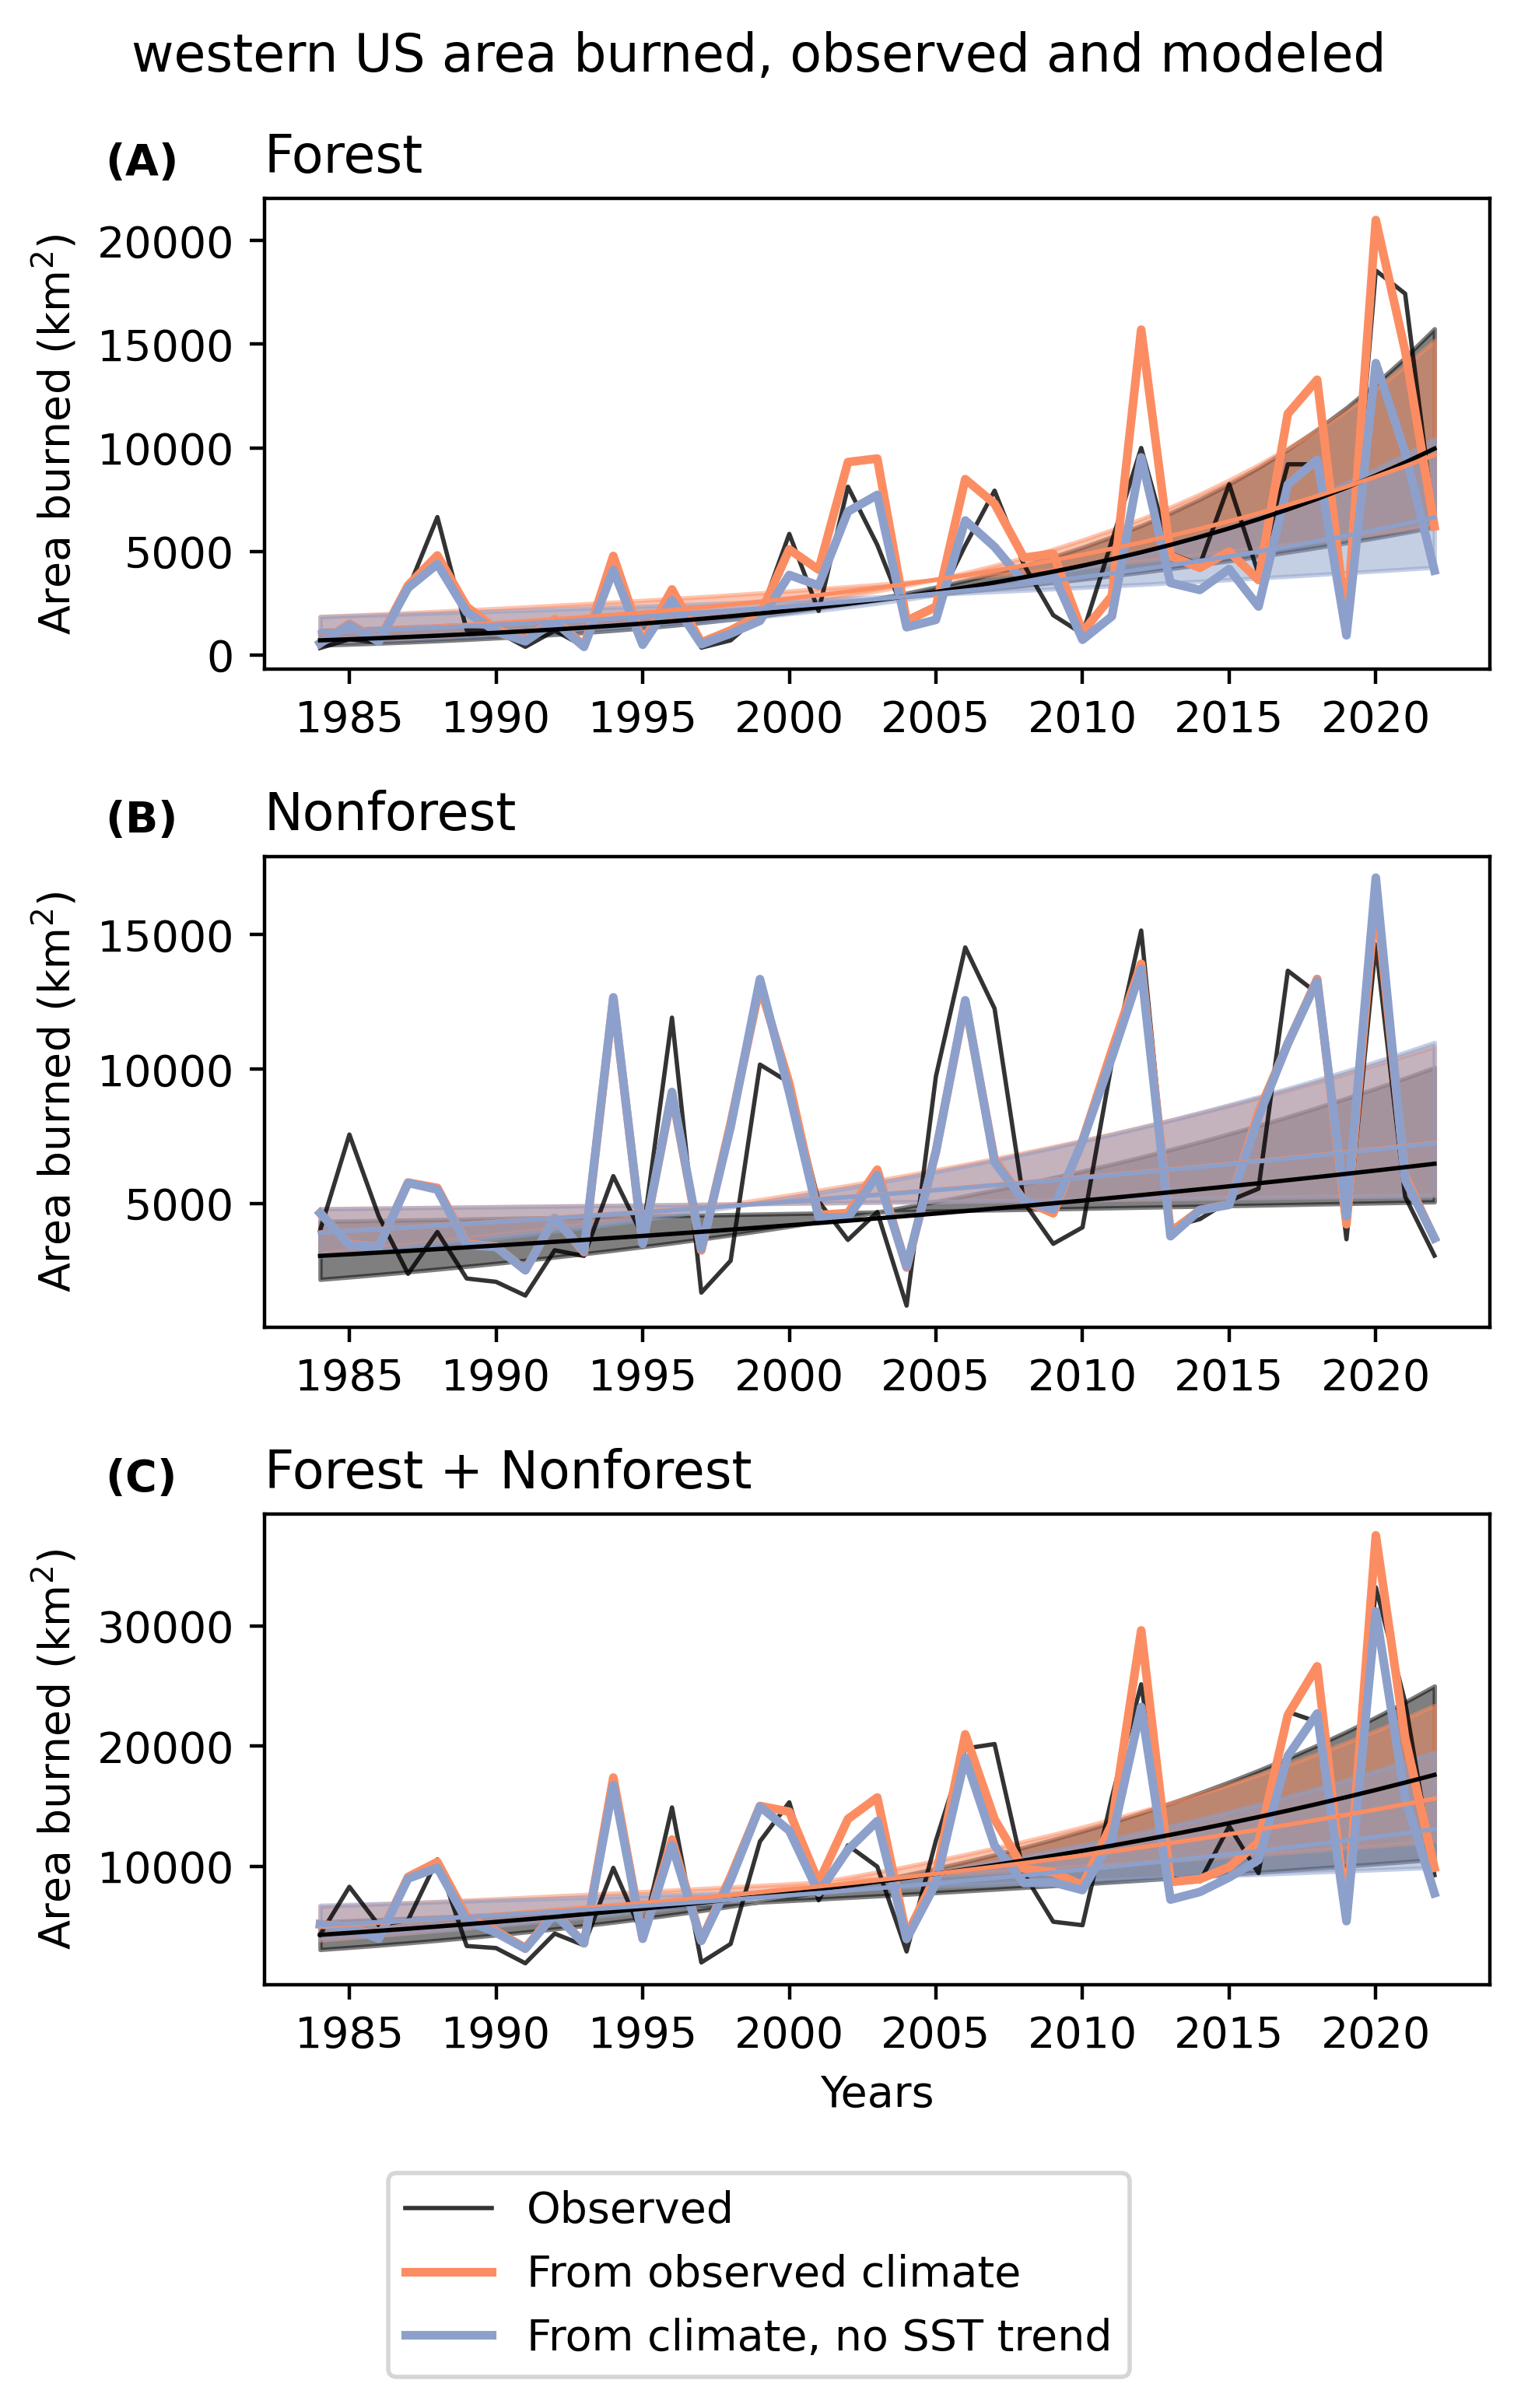

In [74]:
# all of western US area burned, observed and modeled FOREST

# final years
xyears = np.arange(firstyear,finalyear+1,1)
# sum every ecoregion to get entire western US BA
sum_BAclimpredfor = (10**(BAclimpredfor.loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
sum_BAclimpredfor_DT = (10**(BAclimpredfor_DT.loc[:,dfnames[1:]])).sum(axis=1)
sum_BAclimprednon = (10**(BAclimprednon.loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
sum_BAclimprednon_DT = (10**(BAclimprednon_DT.loc[:,dfnames[1:]])).sum(axis=1)
sum_BAclimpredall = sum_BAclimpredfor + sum_BAclimprednon # sum of forest and nonforest
sum_BAclimpredall_DT = sum_BAclimpredfor_DT + sum_BAclimprednon_DT

# put them together
sumswumi = [wumifor.loc[:,'0'], wuminon.loc[:,'0'], wumi.loc[:,'0'], ]
sumsBA = [sum_BAclimpredfor, sum_BAclimprednon,sum_BAclimpredall, ]
sumsBA_DT = [sum_BAclimpredfor_DT, sum_BAclimprednon_DT,sum_BAclimpredall_DT, ]

# line of best fit
tmpm = np.zeros(3)
tmpmBA = np.zeros(3)
tmpmBA_DT = np.zeros(3)
tmpb = np.zeros(3)
tmpbBA = np.zeros(3)
tmpbBA_DT = np.zeros(3)
tmphi = np.zeros(3)
tmphiBA = np.zeros(3)
tmphiBA_DT = np.zeros(3)

tmplo = np.zeros(3)
tmploBA = np.zeros(3)
tmploBA_DT = np.zeros(3)

tmpb_lo = np.zeros(3)
tmpb_hi = np.zeros(3)
tmpbBA_lo = np.zeros(3)
tmpbBA_hi = np.zeros(3)
tmpbBA_DT_lo = np.zeros(3)
tmpbBA_DT_hi = np.zeros(3)

for i in np.arange(len(tmpm)):
    # wumi lines of best fit
    tmpbestfit = theilslopes(np.log10(sumswumi[i]), x=xyears, method='joint') # regression
    tmpm[i] = tmpbestfit.slope
    tmpb[i] = tmpbestfit.intercept
    tmphi[i] = tmpbestfit.high_slope
    tmplo[i] = tmpbestfit.low_slope
    # BA model lines of best fit
    tmpbestfit = theilslopes(np.log10(sumsBA[i]), x=xyears, method='joint') # regression
    tmpmBA[i] = tmpbestfit.slope
    tmpbBA[i] = tmpbestfit.intercept
    tmphiBA[i] = tmpbestfit.high_slope
    tmploBA[i] = tmpbestfit.low_slope
    # detrended BA model lines of best fit
    tmpbestfit = theilslopes(np.log10(sumsBA_DT[i]), x=xyears, method='joint') # regression
    tmpmBA_DT[i] = tmpbestfit.slope
    tmpbBA_DT[i] = tmpbestfit.intercept
    tmphiBA_DT[i] = tmpbestfit.high_slope
    tmploBA_DT[i] = tmpbestfit.low_slope

    # get new b based on high and low slopes
    ylog = np.log10(sumswumi[i])
    # get intercepts
    tmpb_lo[i]  = np.median(ylog - tmplo[i] * xyears)
    tmpb_hi[i] = np.median(ylog - tmphi[i] * xyears)
    
    ylog = np.log10(sumsBA[i])
    # get intercepts
    tmpbBA_lo[i]  = np.median(ylog - tmploBA[i] * xyears)
    tmpbBA_hi[i] = np.median(ylog - tmphiBA[i] * xyears)
    
    ylog = np.log10(sumsBA_DT[i])
    # get intercepts
    tmpbBA_DT_lo[i]  = np.median(ylog - tmploBA_DT[i] * xyears)
    tmpbBA_DT_hi[i] = np.median(ylog - tmphiBA_DT[i] * xyears)

# make plot
fig, ax = plt.subplots(3,1, figsize=(5,7))

fig.suptitle('western US area burned, observed and modeled')
for i in np.arange(0,3):
    # plot area burned
    ax[i].plot(xyears, sumswumi[i], label='Observed', 
               c='k', alpha=0.8, linewidth=1)
    ax[i].plot(xyears, sumsBA[i], 
               label='From observed climate', 
               c=colorobs, linewidth=2)
    ax[i].plot(xyears, sumsBA_DT[i], 
               label='From climate, no SST trend', 
               c=colorDT, linewidth=2)
    # plot lines of best fit
    ax[i].plot(xyears, 10**(tmpm[i]*xyears+tmpb[i]), 
               linewidth=1, c='k', zorder=3)
    ax[i].plot(xyears, 10**(tmpmBA[i]*xyears+tmpbBA[i]), 
               linewidth=1,c=colorobs, zorder=3)
    ax[i].plot(xyears, 10**(tmpmBA_DT[i]*xyears+tmpbBA_DT[i]), 
               linewidth=1,  c=colorDT, zorder=3)

    # plot theil-sen uncertainty ranges
    
    ax[i].fill_between(xyears, 
               10**(tmplo[i]*xyears+tmpb_lo[i]), 
               10**(tmphi[i]*xyears+tmpb_hi[i]), 
               linewidth=1, color='k', alpha=0.5, zorder=0)
    ax[i].fill_between(xyears, 
               10**(tmploBA[i]*xyears+tmpbBA_lo[i]), 
               10**(tmphiBA[i]*xyears+tmpbBA_hi[i]), 
               linewidth=1,color=colorobs, alpha=0.5, zorder=0)
    ax[i].fill_between(xyears, 
               10**(tmploBA_DT[i]*xyears+tmpbBA_DT_lo[i]),
               10**(tmphiBA_DT[i]*xyears+tmpbBA_DT_hi[i]),
               linewidth=1, color=colorDT, alpha=0.5, zorder=0)
    
    # decorate
    ax[i].set_ylabel('Area burned (km$^2$)')


# line of best fit
for i in np.arange(0,3):
    corr_climpred = pearsonr(np.log10(sumswumi[i]), 
                             np.log10(sumsBA[i]))
    #ax[i].annotate("r$^2$(log(BA_obs), log(BA_climate obs) = {:.2f}".format((corr_climpred.rvalue**2)), 
    #            (0.06,0.75), c=colorobs, xycoords='axes fraction' )
    corr_climpred_DT = pearsonr(np.log10(sumswumi[i]), 
                                np.log10(sumsBA_DT[i]))
    #ax[i].annotate("r$^2$(log(BA_obs),log(BA_clim, no SST trend)) = {:.2f}".format(corr_climpred_DT.rvalue**2), 
    #        (0.06,0.65), c=colorDT, xycoords='axes fraction' )
    print('r (log(BA_WUMI), log(BA_from obs clim):', '{:.3}'.format(corr_climpred.statistic))
    print('r (log(BA_WUMI), log(BA_from clim, no SST trend):', '{:.3}'.format(corr_climpred_DT.statistic))

ax[2].set_xlabel('Years')
fig.legend(['Observed', 'From observed climate', 
            'From climate, no SST trend'], 
           bbox_to_anchor=(0.5,-0.05), loc='center')
ax[2].set_title('Forest + Nonforest', loc='left')
ax[0].set_title('Forest', loc='left')
ax[1].set_title('Nonforest', loc='left')
#ax[0].set_ylim([0,25000])
#ax[1].set_ylim([0,20000])
#ax[2].set_ylim([0,40000])
fig.tight_layout()

# add figure labels
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
k = 0
for thisrow in np.arange(0,3):
    thisfiglabel = figlabels[k]
    ax[thisrow].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.05), 
                                 c='k', xycoords='axes fraction')
    k+=1

plt.savefig(figfolder + 'Fig4CombinedBurnModel_R2Runcertainty.png', 
            bbox_inches='tight')

## Sensitivity Analysis: what is the range based on nudging the gSST by 2 degrees?

0.88
r (log(BA_WUMI), log(BA_from obs clim): 0.951
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.935
0.88
r (log(BA_WUMI), log(BA_from obs clim): 0.833
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.826
0.88
r (log(BA_WUMI), log(BA_from obs clim): 0.908
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.896
0.78
r (log(BA_WUMI), log(BA_from obs clim): 0.952
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.935
0.78
r (log(BA_WUMI), log(BA_from obs clim): 0.834
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.83
0.78
r (log(BA_WUMI), log(BA_from obs clim): 0.909
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.896
0.6799999999999999
r (log(BA_WUMI), log(BA_from obs clim): 0.952
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.932
0.6799999999999999
r (log(BA_WUMI), log(BA_from obs clim): 0.829
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.829
0.6799999999999999
r (log(BA_WUMI), log(BA_from obs clim): 0.908
r (log(BA_WUMI), log(BA_from clim, no SST trend): 0.

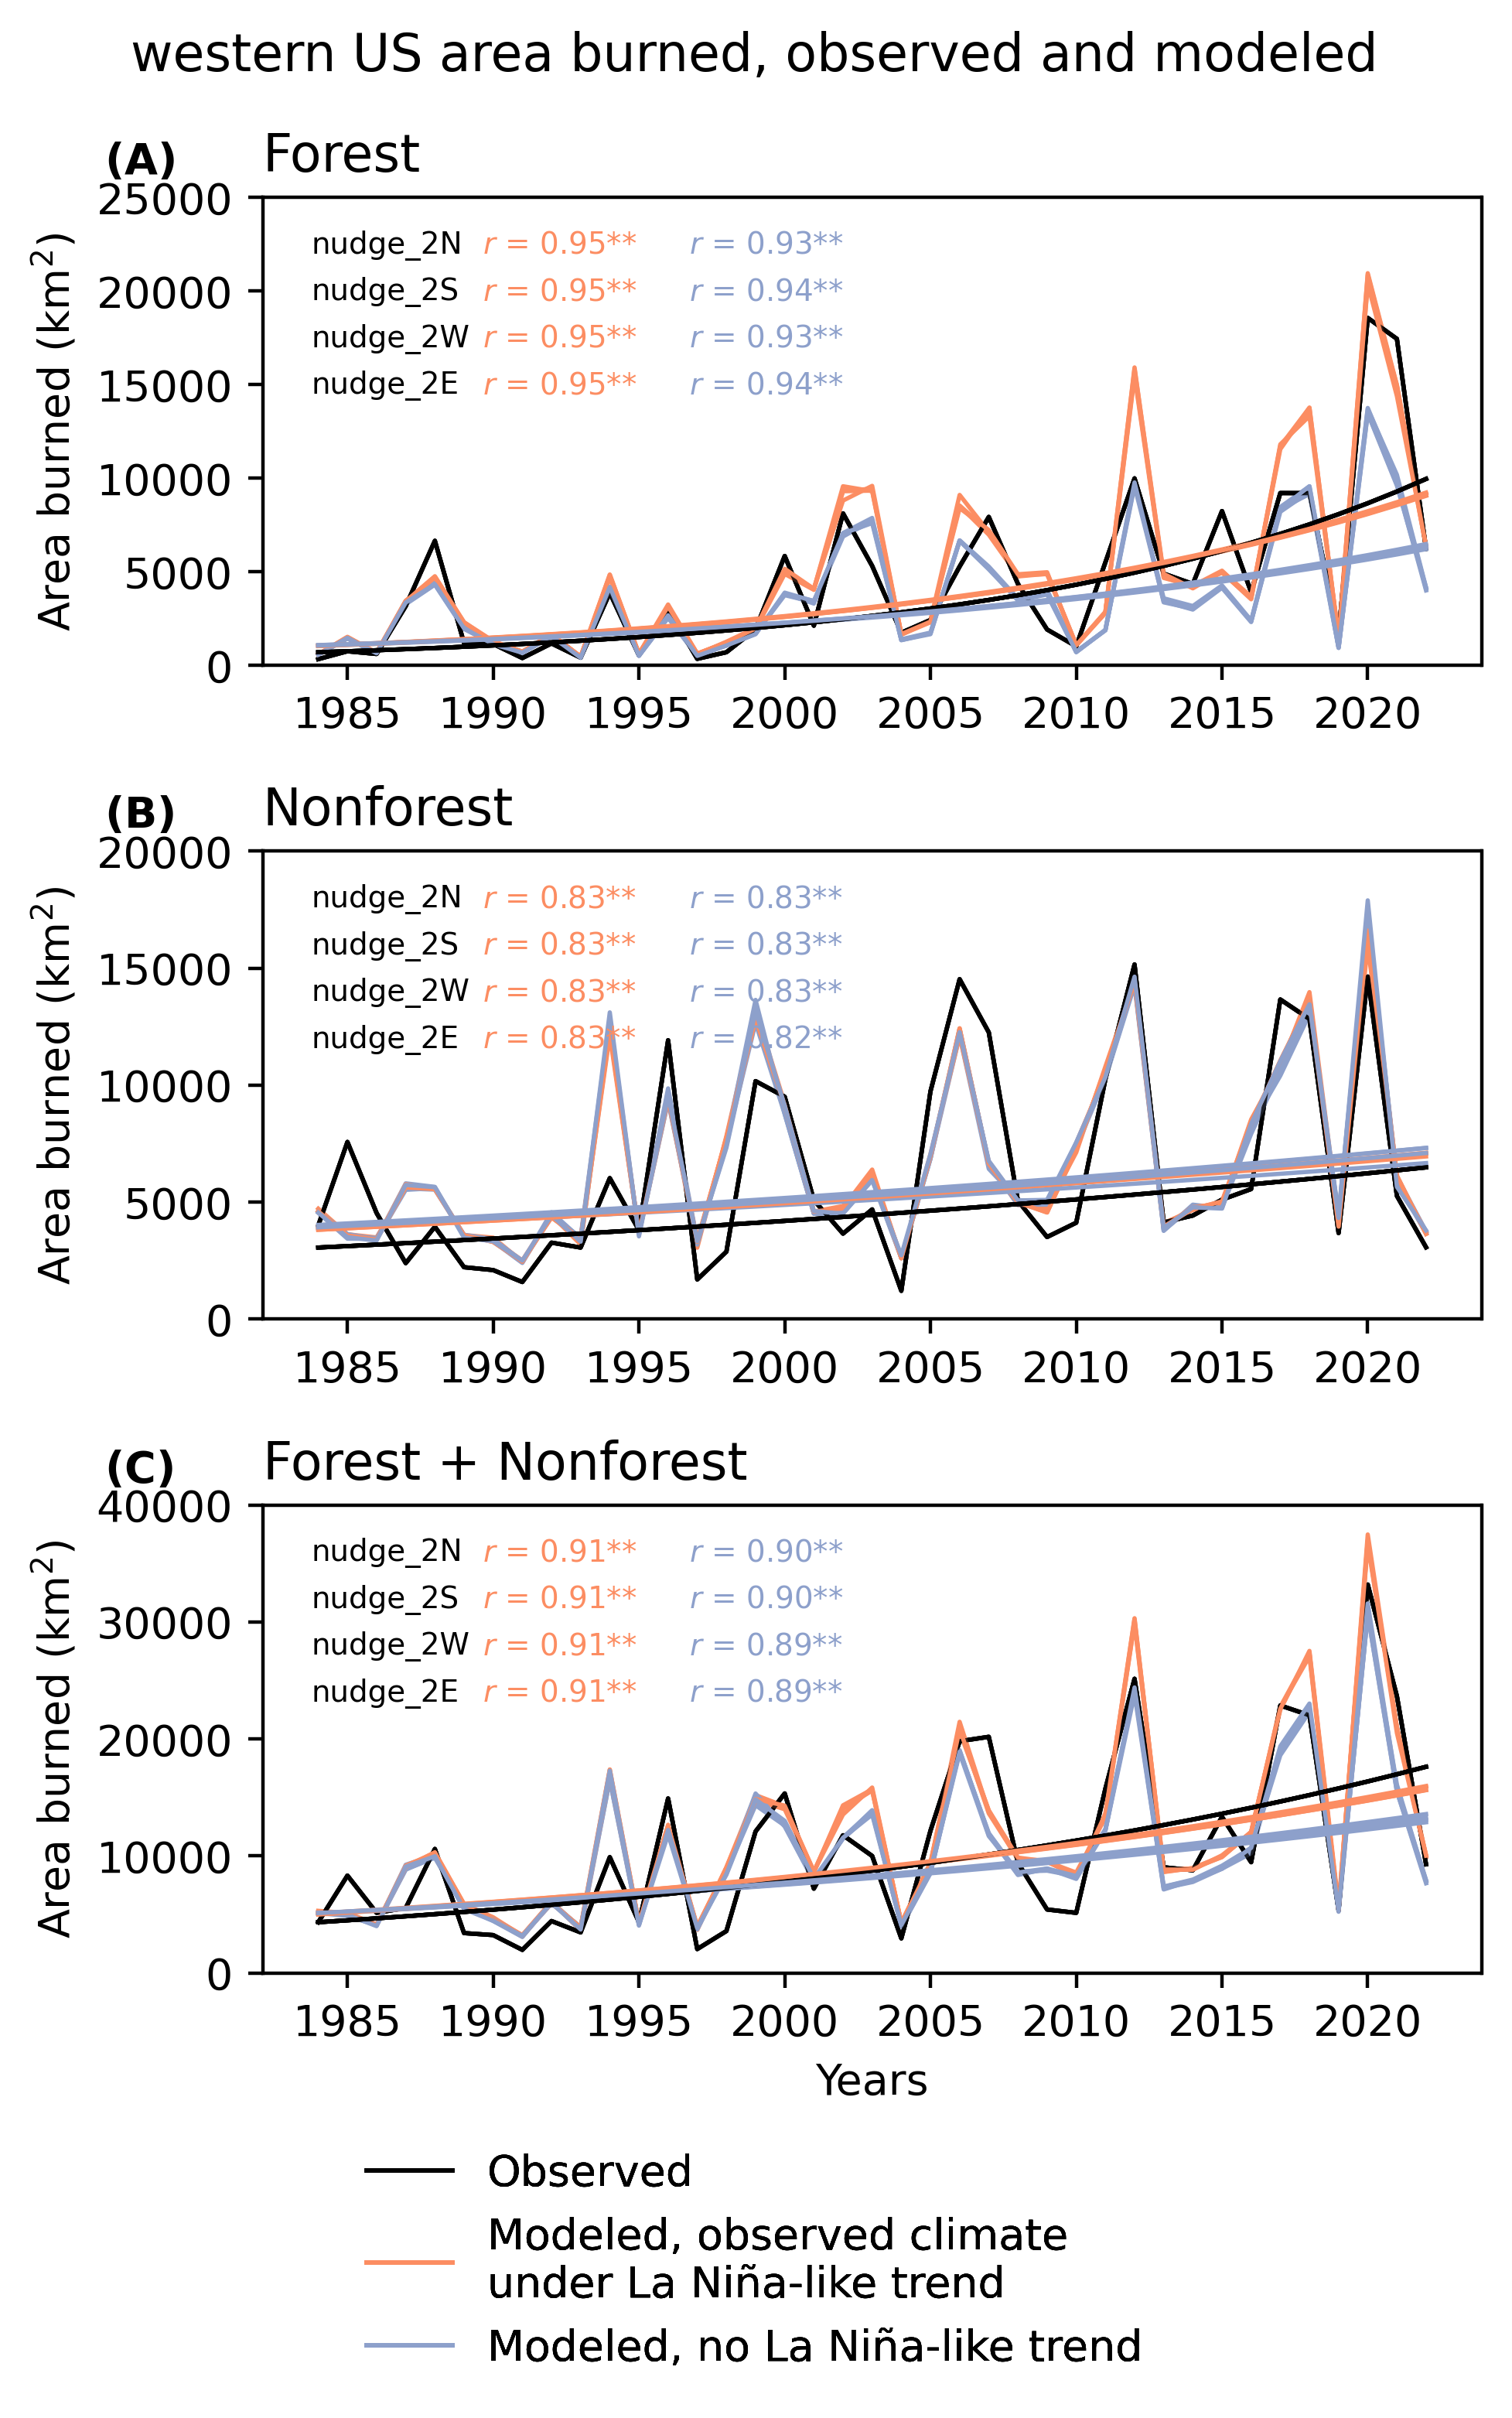

In [17]:
# sensitivity analysis: nudged SSTs all on the Figure 4 time series plot

tmpBAsetfor = [BAclimpredfora, BAclimpredforb, BAclimpredforc, BAclimpredford]
tmpBAsetfor_DT = [BAclimpredfor_DTa, BAclimpredfor_DTb, BAclimpredfor_DTc, BAclimpredfor_DTd]
tmpBAsetnon = [BAclimprednona, BAclimprednonb, BAclimprednonc, BAclimprednona, BAclimprednond]
tmpBAsetnon_DT = [BAclimprednon_DTa, BAclimprednon_DTb, BAclimprednon_DTc, BAclimprednon_DTd]
inudgelist = np.arange(len(tmpBAsetfor))

# make plot
fig, ax = plt.subplots(3,1, figsize=(5,7))

# final years
xyears = np.arange(firstyear,finalyear+1,1)

for inudge in inudgelist:
    # sum every ecoregion to get entire western US BA
    sum_BAclimpredfor = (10**(tmpBAsetfor[inudge].loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
    sum_BAclimpredfor_DT = (10**(tmpBAsetfor_DT[inudge].loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAclimprednon = (10**(tmpBAsetnon[inudge].loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
    sum_BAclimprednon_DT = (10**(tmpBAsetnon_DT[inudge].loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAclimpredall = sum_BAclimpredfor + sum_BAclimprednon # sum of forest and nonforest
    sum_BAclimpredall_DT = sum_BAclimpredfor_DT + sum_BAclimprednon_DT
    
    # put them together
    sumswumi = [wumifor.loc[:,'0'], wuminon.loc[:,'0'], wumi.loc[:,'0']]
    sumsBA = [sum_BAclimpredfor, sum_BAclimprednon, sum_BAclimpredall]
    sumsBA_DT = [sum_BAclimpredfor_DT, sum_BAclimprednon_DT, sum_BAclimpredall_DT]
    
    # line of best fit
    tmpm = np.zeros(3)
    tmpmBA = np.zeros(3)
    tmpmBA_DT = np.zeros(3)
    tmpb = np.zeros(3)
    tmpbBA = np.zeros(3)
    tmpbBA_DT = np.zeros(3)
    for i in np.arange(len(tmpm)):
        # wumi lines of best fit
        tmpbestfit = theilslopes(np.log10(sumswumi[i]), x=xyears, method='joint') # regression
        tmpm[i] = tmpbestfit.slope
        tmpb[i] = tmpbestfit.intercept
        # BA model lines of best fit
        tmpbestfit = theilslopes(np.log10(sumsBA[i]), x=xyears, method='joint') # regression
        tmpmBA[i] = tmpbestfit.slope
        tmpbBA[i] = tmpbestfit.intercept
        # detrended BA model lines of best fit
        tmpbestfit = theilslopes(np.log10(sumsBA_DT[i]), x=xyears, method='joint') # regression
        tmpmBA_DT[i] = tmpbestfit.slope
        tmpbBA_DT[i] = tmpbestfit.intercept
    
    
    
    fig.suptitle('western US area burned, observed and modeled')
    for i in np.arange(0,3):
        # plot area burned
        ax[i].plot(sumswumi[i], label='Observed', 
                   c='k', alpha=0.8, linewidth=1, zorder=2)
        ax[i].plot(xyears, sumsBA[i], 
                   label='From observed climate', 
                   c=colorobs, linewidth=1)
        ax[i].plot(xyears, sumsBA_DT[i], 
                   label='From climate, no SST trend', 
                   c=colorDT, linewidth=1)
        # plot lines of best fit
        ax[i].plot(xyears, 10**(tmpm[i]*xyears+tmpb[i]), 
                   linewidth=1, c='k', zorder=3)
        ax[i].plot(xyears, 10**(tmpmBA[i]*xyears+tmpbBA[i]), 
                   linewidth=1,c=colorobs, zorder=3)
        ax[i].plot(xyears, 10**(tmpmBA_DT[i]*xyears+tmpbBA_DT[i]), 
                   linewidth=1,  c=colorDT, zorder=3)
        # decorate
        ax[i].set_ylabel('Area burned (km$^2$)')
    
    
    # line of best fit
    figlabels = ['nudge_2N', 'nudge_2S', 'nudge_2W', 'nudge_2E']
    tmpsize = 7
    for i in np.arange(0,3):
        frac_fromtop = 0.88-(inudge*0.10)
        print(frac_fromtop)
        corr_climpred = pearsonr(np.log10(sumswumi[i]), 
                                 np.log10(sumsBA[i]))
        corr_pval = addSigMarker(corr_climpred.pvalue)
        ax[i].annotate("{:}".format(figlabels[inudge]), 
                (0.04,frac_fromtop), c='k', fontsize=tmpsize,
                       xycoords='axes fraction' )
        ax[i].annotate("$r$ = {:.2f}{:}".format(corr_climpred.statistic, corr_pval), 
                (0.18,frac_fromtop), c=colorobs, fontsize=tmpsize,
                       xycoords='axes fraction' )
        corr_climpred_DT = pearsonr(np.log10(sumswumi[i]), 
                                    np.log10(sumsBA_DT[i]))
        corr_pval = addSigMarker(corr_climpred_DT.pvalue)
        ax[i].annotate("$r$ = {:.2f}{:}".format(corr_climpred_DT.statistic, corr_pval), 
                (0.35, frac_fromtop), c=colorDT, fontsize=tmpsize,
                       xycoords='axes fraction' )
        print('r (log(BA_WUMI), log(BA_from obs clim):', '{:.3}'.format(corr_climpred.statistic))
        print('r (log(BA_WUMI), log(BA_from clim, no SST trend):', '{:.3}'.format(corr_climpred_DT.statistic))

    ax[2].set_xlabel('Years')
    fig.legend(['Observed', 
                'Modeled, observed climate \nunder La Niña-like trend', 
                'Modeled, no La Niña-like trend'], frameon=False, 
               bbox_to_anchor=(0.5,-0.05), loc='center')
    ax[2].set_title('Forest + Nonforest', loc='left')
    ax[0].set_title('Forest', loc='left')
    ax[1].set_title('Nonforest', loc='left')
    ax[0].set_ylim([0,25000])
    ax[1].set_ylim([0,20000])
    ax[2].set_ylim([0,40000])
    fig.tight_layout()


# add figure labels
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
k = 0
for thisrow in np.arange(0,3):
    thisfiglabel = figlabels[k]
    ax[thisrow].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.05), 
                                 c='k', xycoords='axes fraction')
    k+=1

#plt.savefig(figfolder + 'Fig4CombinedBurnModel_SupplNudge.png', 
#            bbox_inches='tight')

0.88
r (log(BA_DT), log(BA_DT nudged)): 1.0
0.88
r (log(BA_DT), log(BA_DT nudged)): 0.998
0.88
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.88
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.88
r (log(BA_DT), log(BA_DT nudged)): 0.998
0.88
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.78
r (log(BA_DT), log(BA_DT nudged)): 1.0
0.78
r (log(BA_DT), log(BA_DT nudged)): 0.998
0.78
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.78
r (log(BA_DT), log(BA_DT nudged)): 1.0
0.78
r (log(BA_DT), log(BA_DT nudged)): 0.998
0.78
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.6799999999999999
r (log(BA_DT), log(BA_DT nudged)): 1.0
0.6799999999999999
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.6799999999999999
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.6799999999999999
r (log(BA_DT), log(BA_DT nudged)): 1.0
0.6799999999999999
r (log(BA_DT), log(BA_DT nudged)): 0.998
0.6799999999999999
r (log(BA_DT), log(BA_DT nudged)): 0.999
0.58
r (log(BA_DT), log(BA_DT nudged)): 1.0
0.58
r (log(BA_DT), log(BA_DT nudged)): 0.998
0.58
r (

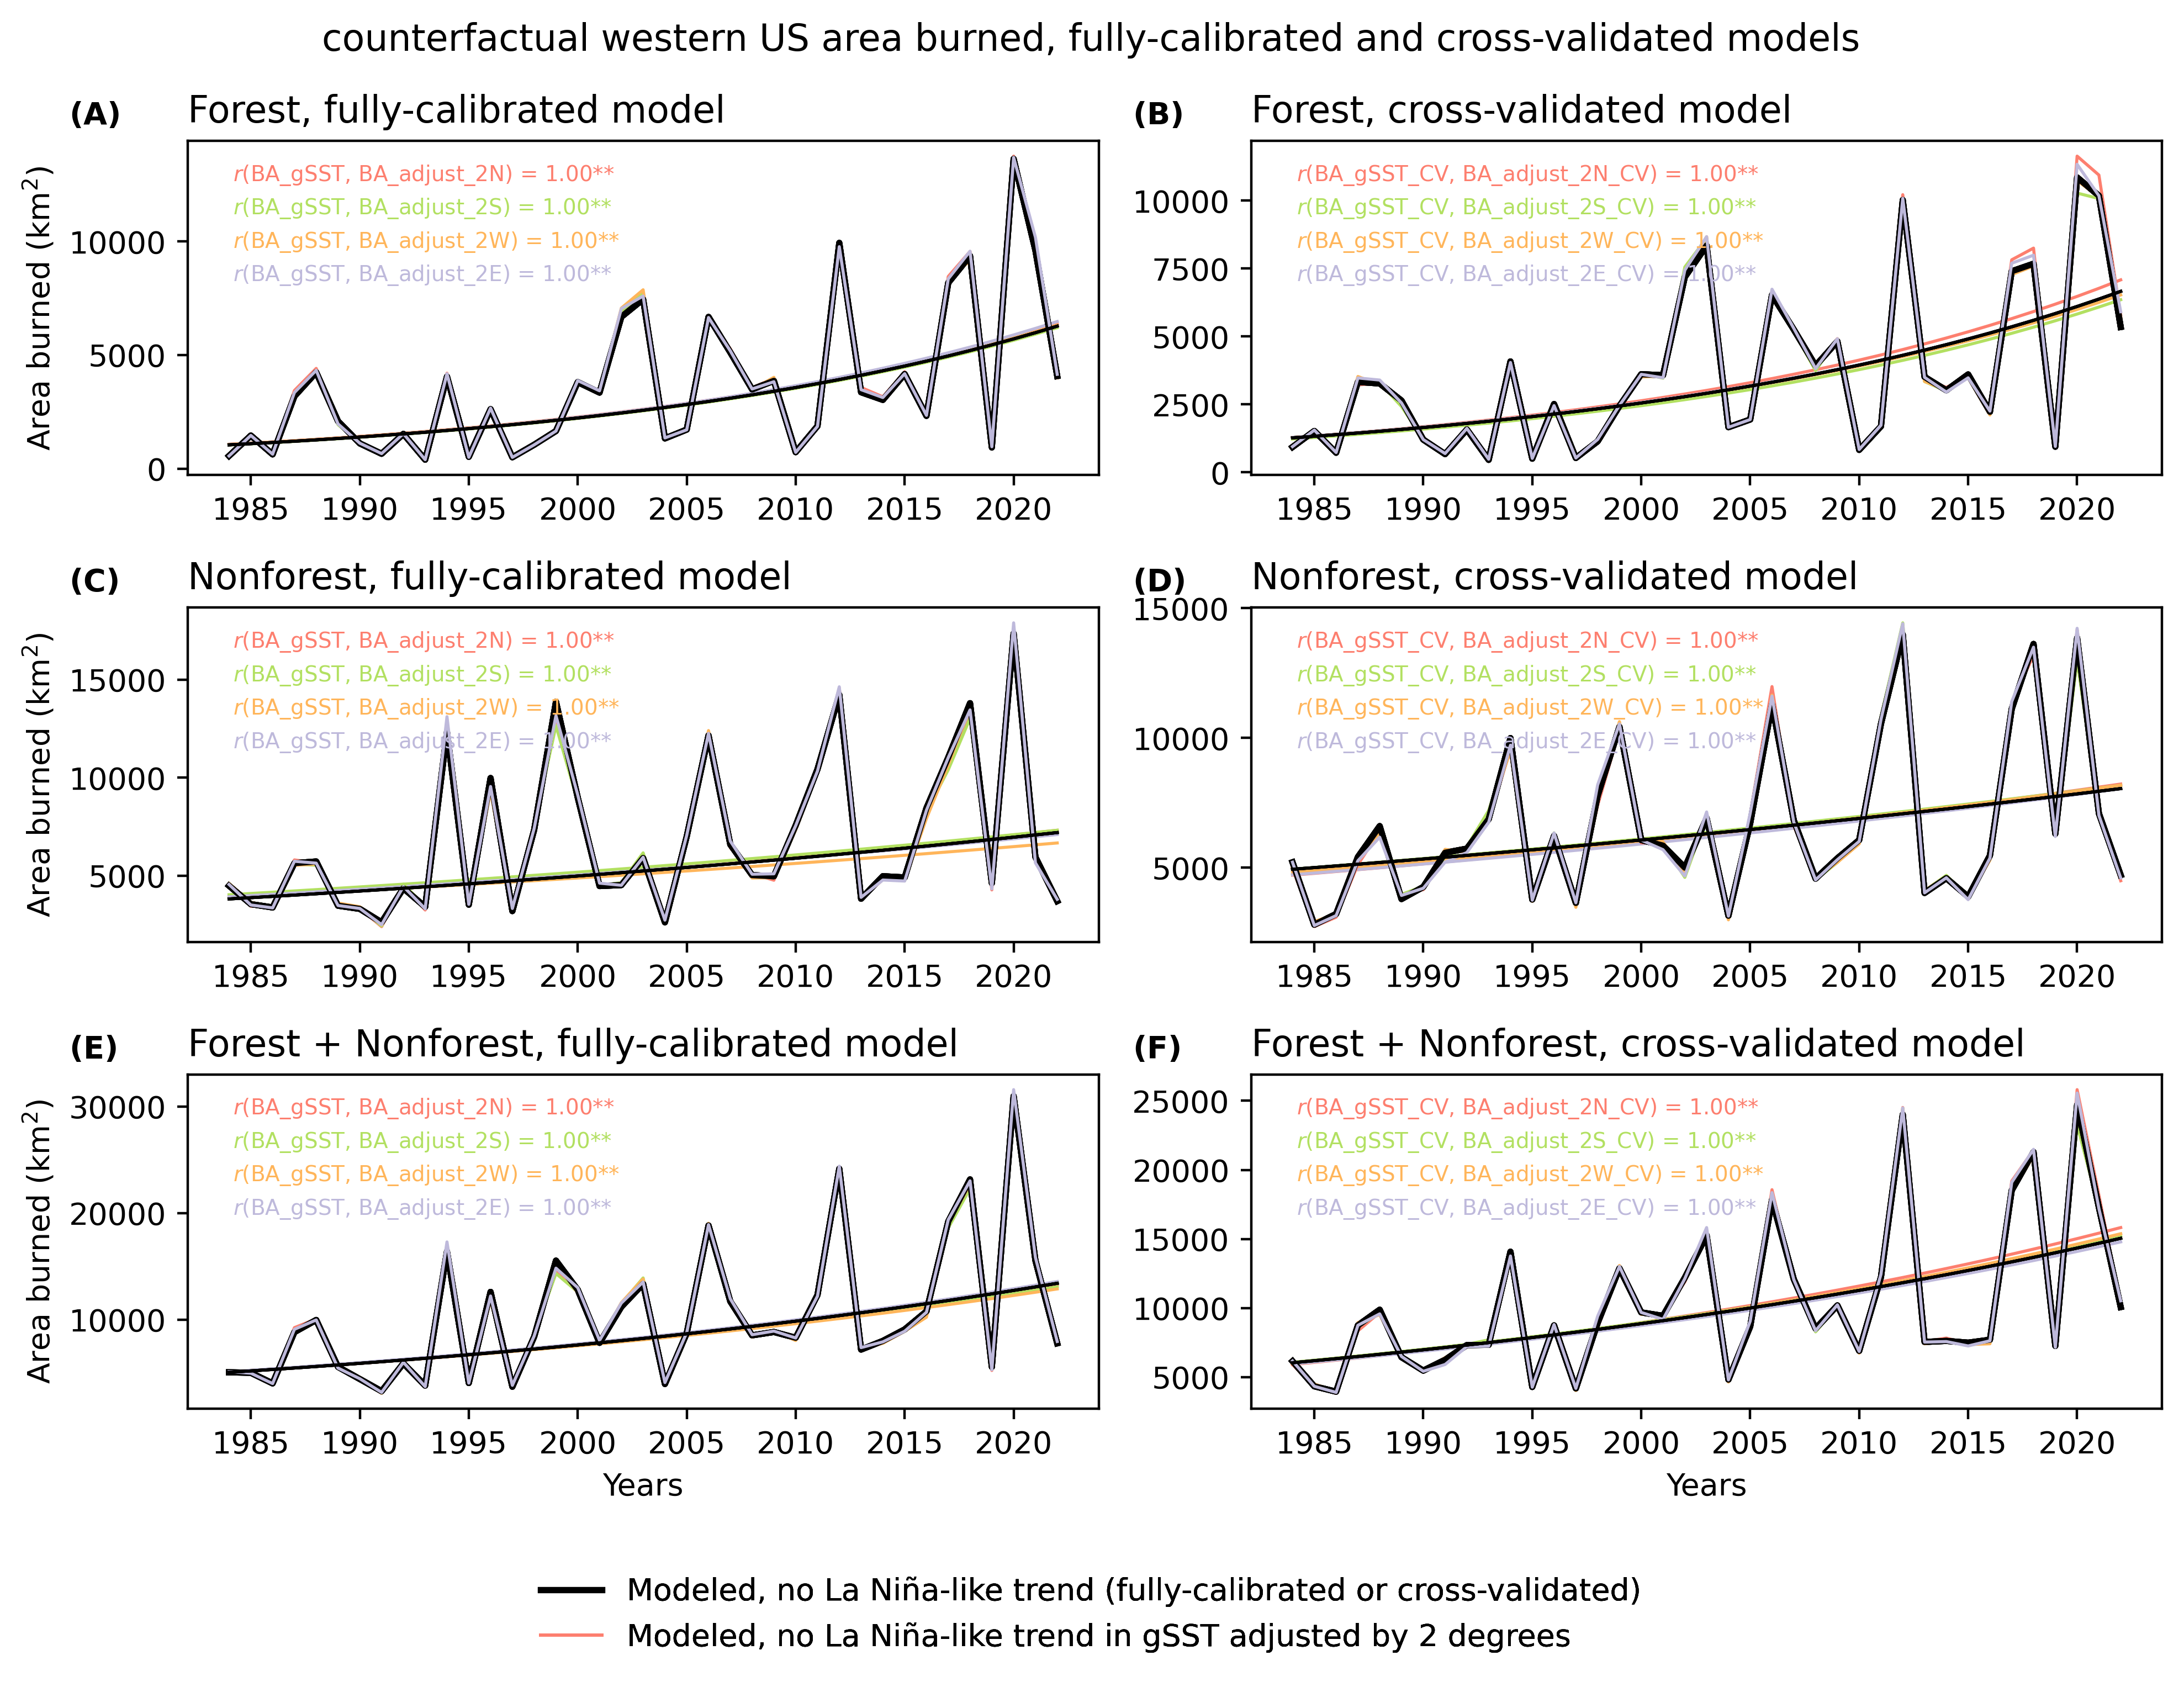

In [47]:
# sensitivity analysis take 2
# show plots without observed data
# just the detrended estimate

color1 = 'k'
color2 = 'darkviolet'
color3 = ["#fd7f6f", "#b2e061", "#ffb55a","#beb9db", "#fdcce5", "#8bd3c7"]

# original gSST
sum_BAclimpredfor_DT = (10**(BAclimpredfor_DT.loc[:,dfnames[1:]])).sum(axis=1)
sum_BAclimprednon_DT = (10**(BAclimprednon_DT.loc[:,dfnames[1:]])).sum(axis=1)
sum_BAclimpredall_DT = sum_BAclimpredfor_DT + sum_BAclimprednon_DT
sumsBA_DT = [sum_BAclimpredfor_DT, sum_BAclimprednon_DT,sum_BAclimpredall_DT, ]

# original gSST, cross-validated

sum_BACVclimpredfor_DT = (10**(BACVsstfor_DT.loc[:,dfnames[1:]])).sum(axis=1)
sum_BACVclimprednon_DT = (10**(BACVsstnon_DT.loc[:,dfnames[1:]])).sum(axis=1)
sum_BACVclimpredall_DT = sum_BACVclimpredfor_DT + sum_BACVclimprednon_DT
sumsBACV_DT = [sum_BACVclimpredfor_DT, sum_BACVclimprednon_DT,sum_BACVclimpredall_DT, ]


# nudged gSSTs 
tmpBAsetfor_DT = [BAclimpredfor_DTa, BAclimpredfor_DTb, BAclimpredfor_DTc, BAclimpredfor_DTd]
tmpBAsetnon_DT = [BAclimprednon_DTa, BAclimprednon_DTb, BAclimprednon_DTc, BAclimprednon_DTd]
tmpBAsetCVfor_DT = [BACVsstfor_DTa, BACVsstfor_DTb, BACVsstfor_DTc, BACVsstfor_DTd]
tmpBAsetCVnon_DT = [BACVsstnon_DTa, BACVsstnon_DTb, BACVsstnon_DTc, BACVsstnon_DTd]

inudgelist = np.arange(len(tmpBAsetfor_DT))

# make plot
fig, ax = plt.subplots(3,2, figsize=(10,7))

# final years
xyears = np.arange(firstyear,finalyear+1,1)

for inudge in inudgelist:
    # pick nudged gSST (a,b,c,or d)
    sum_BAsetpredfor_DT = (10**(tmpBAsetfor_DT[inudge].loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAsetprednon_DT = (10**(tmpBAsetnon_DT[inudge].loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAsetpredall_DT = sum_BAsetpredfor_DT + sum_BAsetprednon_DT

    sum_basetCVfor_DT = (10**(tmpBAsetCVfor_DT[inudge].loc[:,dfnames[1:]])).sum(axis=1)
    sum_basetCVnon_DT = (10**(tmpBAsetCVnon_DT[inudge].loc[:,dfnames[1:]])).sum(axis=1)
    sum_basetCVall_DT = (sum_basetCVfor_DT + sum_basetCVnon_DT)
    
    # put them together
    sumssetBA_DT = [sum_BAsetpredfor_DT, sum_BAsetprednon_DT, sum_BAsetpredall_DT]
    sumssetBACV_DT = [sum_basetCVfor_DT, sum_basetCVnon_DT, sum_basetCVall_DT]
    
    # line of best fit
    tmpmBA_DT = np.zeros(3)
    tmpmBACV_DT = np.zeros(3)
    tmpmBAnudge = np.zeros(3)
    tmpmBAnudgeCV = np.zeros(3)
    tmpbBA_DT = np.zeros(3)
    tmpbBACV_DT = np.zeros(3)
    tmpbBAnudge = np.zeros(3)
    tmpbBAnudgeCV = np.zeros(3)
    for i in np.arange(len(tmpmBA_DT)): # iterate through forest, nonforest
        # OG detrended BA model lines of best fit
        tmpbestfit = theilslopes(np.log10(sumsBA_DT[i]), x=xyears, method='joint') # regression
        tmpmBA_DT[i] = tmpbestfit.slope
        tmpbBA_DT[i] = tmpbestfit.intercept
        # nudged gSST detrended BA model lines of best fit
        tmpbestfit = theilslopes(np.log10(sumssetBA_DT[i]), x=xyears, method='joint') # regression
        tmpmBAnudge[i] = tmpbestfit.slope
        tmpbBAnudge[i] = tmpbestfit.intercept

        # OG cross-validated detrened BA model lines of best fit
        tmpbestfit = theilslopes(np.log10(sumsBACV_DT[i]), x=xyears, method='joint') # regression
        tmpmBACV_DT[i] = tmpbestfit.slope
        tmpbBACV_DT[i] = tmpbestfit.intercept
        # nudged cross-validated gSST detrended BA model lines of best fit
        tmpbestfit = theilslopes(np.log10(sumssetBACV_DT[i]), x=xyears, method='joint') # regression
        tmpmBAnudgeCV[i] = tmpbestfit.slope
        tmpbBAnudgeCV[i] = tmpbestfit.intercept
    
    fig.suptitle('counterfactual western US area burned, fully-calibrated and cross-validated models')
    for i in np.arange(0,3):
        # plot area burned, OG
        ax[i,0].plot(xyears, sumsBA_DT[i], 
                   label='From climate, no SST trend', 
                   c=color1, linewidth=2)
        
        # plot nudged gSSTs
        ax[i,0].plot(xyears, sumssetBA_DT[i], 
                   label='From climate, no SST trend', 
                   c=color3[inudge], linewidth=1)
       
        # plot area burned, OG, cross validated
        ax[i,1].plot(xyears, sumsBACV_DT[i], 
                   label='From climate, no SST trend', 
                   c=color1, linewidth=2)
        
        # plot nudged gSSTs, cross validated
        ax[i,1].plot(xyears, sumssetBACV_DT[i], 
                   label='From climate, no SST trend', 
                   c=color3[inudge], linewidth=1)
        

        # lines of best fit
        # plot lines of best fit OG
        ax[i,0].plot(xyears, 10**(tmpmBA_DT[i]*xyears+tmpbBA_DT[i]), 
                   linewidth=1,  c=color1, zorder=3)
         # plot lines of best fit nudged gSST
        ax[i,0].plot(xyears, 10**(tmpmBAnudge[i]*xyears+tmpbBAnudge[i]), 
                   linewidth=1,  c=color3[inudge], zorder=1)
        # plot lines of best fit OG
        ax[i,1].plot(xyears, 10**(tmpmBACV_DT[i]*xyears+tmpbBACV_DT[i]), 
                   linewidth=1,  c=color1, zorder=3)
        # plot lines of best fit nudged gSST
        ax[i,1].plot(xyears, 10**(tmpmBAnudgeCV[i]*xyears+tmpbBAnudgeCV[i]), 
                   linewidth=1,  c=color3[inudge], zorder=1)

        # decorate
        ax[i,0].set_ylabel('Area burned (km$^2$)')
    
    
    # correlation annotate
    figlabels = ['adjust_2N', 'adjust_2S', 'adjust_2W', 'adjust_2E']
    tmpsize = 7
    # FULLY CALIBRATED CORRELATION
    for i in np.arange(0,3):
        frac_fromtop = 0.88-(inudge*0.10)
        print(frac_fromtop)
        corr_climpred_DT = pearsonr(np.log10(sumsBA_DT[i]), 
                                    np.log10(sumssetBA_DT[i]))
        corr_pval = addSigMarker(corr_climpred_DT.pvalue)
        ax[i,0].annotate("$r$(BA_gSST, BA_{:}) = {:.2f}{:}".format(figlabels[inudge], corr_climpred_DT.statistic, corr_pval), 
                (0.05, frac_fromtop), c=color3[inudge], fontsize=tmpsize,
                       xycoords='axes fraction' )
        print('r (log(BA_DT), log(BA_DT nudged)):', '{:.3}'.format(corr_climpred_DT.statistic))
    # CROSS VALIDATED CORRELATION
    for i in np.arange(0,3):
        frac_fromtop = 0.88-(inudge*0.10)
        print(frac_fromtop)
        corr_climpred_DT = pearsonr(np.log10(sumsBACV_DT[i]), 
                                    np.log10(sumssetBACV_DT[i]))
        corr_pval = addSigMarker(corr_climpred_DT.pvalue)
        ax[i,1].annotate("$r$(BA_gSST_CV, BA_{:}_CV) = {:.2f}{:}".format(figlabels[inudge], corr_climpred_DT.statistic, corr_pval), 
                (0.05, frac_fromtop), c=color3[inudge], fontsize=tmpsize,
                       xycoords='axes fraction' )
        print('r (log(BA_DT), log(BA_DT nudged)):', '{:.3}'.format(corr_climpred_DT.statistic))


    fig.legend(['Modeled, no La Niña-like trend (fully-calibrated or cross-validated)', 
                'Modeled, no La Niña-like trend in gSST adjusted by 2 degrees',
               ], frameon=False, 
                bbox_to_anchor=(0.5,-0.05), loc='center')

k=0
ax[2,k].set_xlabel('Years')
ax[2,k].set_title('Forest + Nonforest, fully-calibrated model', loc='left')
ax[0,k].set_title('Forest, fully-calibrated model', loc='left')
ax[1,k].set_title('Nonforest, fully-calibrated model', loc='left')
k=1
ax[2,k].set_xlabel('Years')
ax[2,k].set_title('Forest + Nonforest, cross-validated model', loc='left')
ax[0,k].set_title('Forest, cross-validated model', loc='left')
ax[1,k].set_title('Nonforest, cross-validated model', loc='left')

#for k in np.arange(2):   
    #ax[0,k].set_ylim([0,25000])
    #ax[1,k].set_ylim([0,20000])
    #ax[2,k].set_ylim([0,40000])

fig.tight_layout()



# add figure labels
figlabels = [chr(i) for i in range(65, 65 + len(province_num)+1)]
k = 0
for thisrow in np.arange(0,3):
    for thiscol in np.arange(0,2):
        thisfiglabel = figlabels[k]
        ax[thisrow, thiscol].annotate('$\\bf{(%s)}$' % thisfiglabel, (-0.13,1.05), 
                                     c='k', xycoords='axes fraction')
        k+=1

plt.savefig(figfolder + 'Fig4CombinedBurnModel_SupplNudge.png', 
            bbox_inches='tight')



## Trend from gSST nudged!!

NUDGED 0
How much of the trend is from the SST gradient?
(trendline is Theil-Sen)
ALL
$\Delta$ = 340.67 km$^2$/yr
	% change in observed trendline: 306.23 %
$\Delta$ = 268.86 km$^2$/yr
	% change in model(observed clim): 241.68 %
$\Delta$ = 209.99 km$^2$/yr
	% change in model(DT clim): 188.77 %
How much of the trend? 58.86 km2/yr, 17.28 %
FOREST
$\Delta$ = 237.36 km$^2$/yr
	% change in observed trendline: 1320.05 %
$\Delta$ = 209.11 km$^2$/yr
	% change in model(observed clim): 1162.94 %
$\Delta$ = 135.79 km$^2$/yr
	% change in model(DT clim): 755.18 %
How much of the trend? 73.32 km2/yr, 30.89 %
NONFOREST
$\Delta$ = 87.84 km$^2$/yr
	% change in observed trendline: 111.92 %
$\Delta$ = 79.87 km$^2$/yr
	% change in model(observed clim): 101.76 %
$\Delta$ = 86.97 km$^2$/yr
	% change in model(DT clim): 110.81 %
How much of the trend? -7.10 km2/yr, -8.08 %
NUDGED 1
How much of the trend is from the SST gradient?
(trendline is Theil-Sen)
ALL
$\Delta$ = 340.67 km$^2$/yr
	% change in observed tre

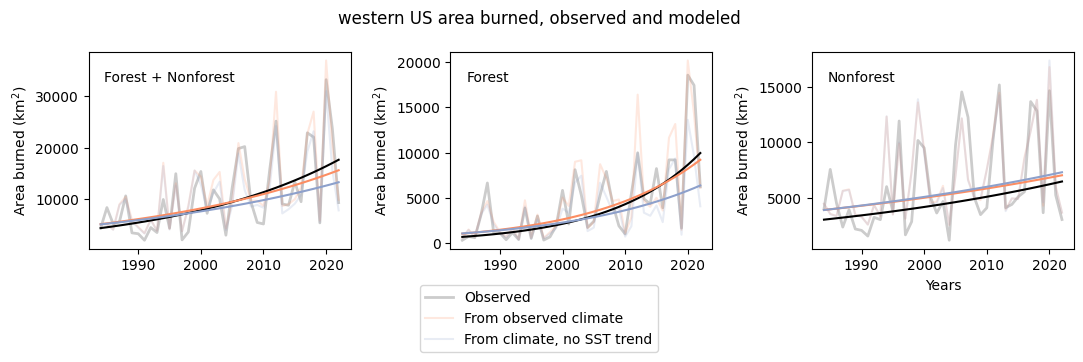

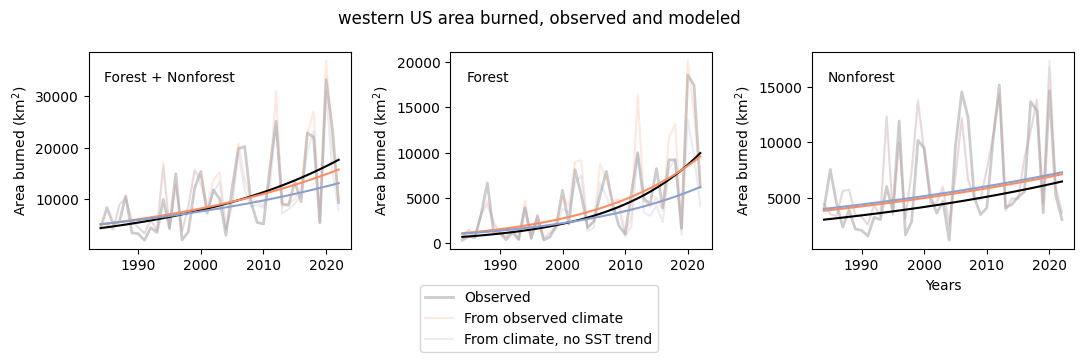

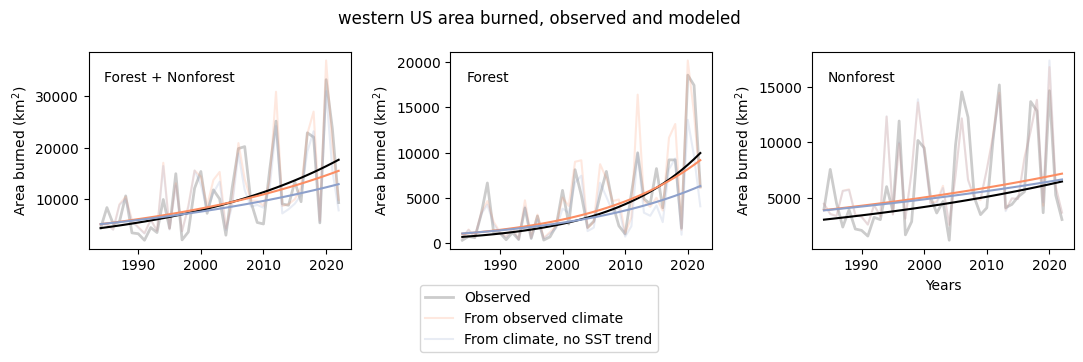

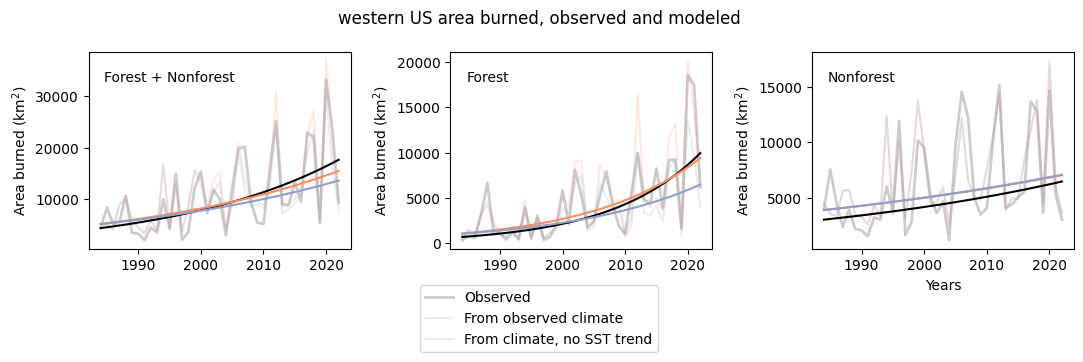

In [46]:
# calculate trend from nudged
# iterate through each nudged gSST

tmpBAsetfor = [BAclimpredfora, BAclimpredforb, BAclimpredforc, BAclimpredford]
tmpBAsetfor_DT = [BAclimpredfor_DTa, BAclimpredfor_DTb, BAclimpredfor_DTc, BAclimpredfor_DTd]
tmpBAsetnon = [BAclimprednona, BAclimprednonb, BAclimprednonc, BAclimprednona, BAclimprednond]
tmpBAsetnon_DT = [BAclimprednon_DTa, BAclimprednon_DTb, BAclimprednon_DTc, BAclimprednon_DTd]
inudgelist = np.arange(len(tmpBAsetfor))

for igSST in inudgelist:
    print('NUDGED '+str(igSST))
    
    # calculate Theil-Sen trendlines
    # (8/8/2024) for timeseries, I make all intercepts the observed BA trendline intercept
    # for proper % comparison. Add the percent change to the figures.
    # sum every ecoregion to get entire western US BA
    sum_BAclimpredfor = (10**(tmpBAsetfor[igSST].loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
    sum_BAclimpredfor_DT = (10**(tmpBAsetfor_DT[igSST].loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAclimprednon = (10**(tmpBAsetnon[igSST].loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
    sum_BAclimprednon_DT = (10**(tmpBAsetnon_DT[igSST].loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAclimpredall = sum_BAclimpredfor + sum_BAclimprednon # sum of forest and nonforest
    sum_BAclimpredall_DT = sum_BAclimpredfor_DT + sum_BAclimprednon_DT

    
    xyears = np.arange(firstyear,finalyear+1,1)
    
    # trendlines from observed BA
    m_all_obs = theilslopes(np.log10(wumi.iloc[:,0]), x=xyears, method='joint')
    m_for_obs = theilslopes(np.log10(wumifor.iloc[:,0]), x=xyears, method='joint')
    m_non_obs = theilslopes(np.log10(wuminon.iloc[:,0]), x=xyears, method='joint')
    
    # trendlines from trended scenario (climate-BA model)
    m_all_clim = theilslopes(np.log10(sum_BAclimpredall), x=xyears, method='joint')
    m_for_clim = theilslopes(np.log10(sum_BAclimpredfor), x=xyears, method='joint')
    m_non_clim = theilslopes(np.log10(sum_BAclimprednon), x=xyears, method='joint')
    
    # trendlines from detrended scenario (climate-BA model)
    m_all_climdt = theilslopes(np.log10(sum_BAclimpredall_DT), x=xyears, method='joint')
    m_for_climdt = theilslopes(np.log10(sum_BAclimpredfor_DT), x=xyears, method='joint')
    m_non_climdt = theilslopes(np.log10(sum_BAclimprednon_DT), x=xyears, method='joint')
    
    # what is the trendline contribution?
    
    # small graph of the trendlines to confirm
    # all of western US area burned, observed and modeled FOREST
    
    # final years
    xyears = np.arange(firstyear,finalyear+1,1)
    # sum every ecoregion to get entire western US BA
    sum_BAclimpredfor = (10**(BAclimpredfor.loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
    sum_BAclimpredfor_DT = (10**(BAclimpredfor_DT.loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAclimprednon = (10**(BAclimprednon.loc[:,dfnames[1:]])).sum(axis=1) # summed across ecoregions
    sum_BAclimprednon_DT = (10**(BAclimprednon_DT.loc[:,dfnames[1:]])).sum(axis=1)
    sum_BAclimpredall = sum_BAclimpredfor + sum_BAclimprednon # sum of forest and nonforest
    sum_BAclimpredall_DT = sum_BAclimpredfor_DT + sum_BAclimprednon_DT
    
    sumswumi = [wumi.loc[:,'0'], wumifor.loc[:,'0'], wuminon.loc[:,'0']]
    sumsBA = [sum_BAclimpredall, sum_BAclimpredfor, sum_BAclimprednon]
    sumsBA_DT = [sum_BAclimpredall_DT, sum_BAclimpredfor_DT, sum_BAclimprednon_DT]
    
    # make plot
    fig, ax = plt.subplots(1,3, figsize=(11,3), dpi=50)
    
    fig.suptitle('western US area burned, observed and modeled')
    for i in np.arange(0,3):
        ax[i].plot(sumswumi[i], label='Observed', c='k', linewidth=2, alpha=0.2)
        ax[i].plot(xyears, sumsBA[i], label='From observed climate', c=colorobs, alpha=0.2)
        ax[i].plot(xyears, sumsBA_DT[i], label='From climate, no SST trend', c=colorDT, alpha=0.2)
        ax[i].set_ylabel('Area burned (km$^2$)')
    
    ax[2].set_xlabel('Years')
    fig.legend(['Observed', 'From observed climate', 'From climate, no SST trend'], bbox_to_anchor=(0.5,-0.05), loc='center')
    ax[0].annotate('Forest + Nonforest',(0.06,0.85), c='#000', xycoords='axes fraction' )
    ax[1].annotate('Forest',(0.06,0.85), c='#000', xycoords='axes fraction' )
    ax[2].annotate('Nonforest',(0.06,0.85), c='#000', xycoords='axes fraction' )
    
    # (8/8/2024) Purposely changed all trendline starts to the observed BA intercept
    # plot 1 trendlines
    ax[0].plot(xyears, 10**(m_all_obs.slope*xyears+m_all_obs.intercept), c='k')
    ax[0].plot(xyears, 10**(m_all_clim.slope*xyears+m_all_clim.intercept), c=colorobs)
    ax[0].plot(xyears, 10**(m_all_climdt.slope*xyears+m_all_climdt.intercept), c=colorDT)
    
    # plot 2 trendlines
    ax[1].plot(xyears, 10**(m_for_obs.slope*xyears+m_for_obs.intercept), c='k')
    ax[1].plot(xyears, 10**(m_for_clim.slope*xyears+m_for_clim.intercept), c=colorobs)
    ax[1].plot(xyears, 10**(m_for_climdt.slope*xyears+m_for_climdt.intercept), c=colorDT)
    
    # plot 3 trendlines
    ax[2].plot(xyears, 10**(m_non_obs.slope*xyears+m_non_obs.intercept), c='k')
    ax[2].plot(xyears, 10**(m_non_clim.slope*xyears+m_non_clim.intercept), c=colorobs)
    ax[2].plot(xyears, 10**(m_non_climdt.slope*xyears+m_non_climdt.intercept), c=colorDT)
    
    fig.tight_layout()
    #plt.savefig(figfolder + 'AGU2022_AreaBurned_models.png')
    
    # print the trendline contribution
    print('How much of the trend is from the SST gradient?\n(trendline is Theil-Sen)')
    
    # calculate the difference in before/after for each to get percent change
    # (8/8/2024) Purposely changed percentage change denominator to be obs BA
    print('ALL')
    tmpinit0 = 10**(m_all_obs.slope*xyears[0]+m_all_obs.intercept)
    tmpfinal = 10**(m_all_obs.slope*xyears[-1]+m_all_obs.intercept)
    rawchange1all= (tmpfinal-tmpinit0)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange1all))
    tmppctchange1all = ((tmpfinal - tmpinit0)/tmpinit0)*100
    print('\t% change in observed trendline: {:.2f} %'.format(tmppctchange1all))
    
    tmpinit = 10**(m_all_clim.slope*xyears[0]+m_all_clim.intercept)
    tmpfinal = 10**(m_all_clim.slope*xyears[-1]+m_all_clim.intercept)
    rawchange2all = (tmpfinal-tmpinit)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange2all))
    tmppctchange2all = ((tmpfinal - tmpinit)/tmpinit0)*100
    print('\t% change in model(observed clim): {:.2f} %'.format(tmppctchange2all))
    
    tmpinit = 10**(m_all_climdt.slope*xyears[0]+m_all_climdt.intercept)
    tmpfinal = 10**(m_all_climdt.slope*xyears[-1]+m_all_climdt.intercept)
    rawchange3all = (tmpfinal-tmpinit)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange3all))
    tmppctchange3all = ((tmpfinal - tmpinit)/tmpinit0)*100
    print('\t% change in model(DT clim): {:.2f} %'.format(tmppctchange3all))
    
    finalrawchange_all = rawchange2all-rawchange3all
    finaltrendper_all = (tmppctchange2all-tmppctchange3all)/tmppctchange1all*100
    print('How much of the trend? {:.2f} km2/yr, {:.2f} %'.format(finalrawchange_all, finaltrendper_all))
    
    
    
    
    
    print('FOREST')
    tmpinit0 = 10**(m_for_obs.slope*xyears[0]+m_for_obs.intercept)
    tmpfinal = 10**(m_for_obs.slope*xyears[-1]+m_for_obs.intercept)
    rawchange1for = (tmpfinal-tmpinit0)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange1for))
    tmppctchange1for = ((tmpfinal - tmpinit0)/tmpinit0)*100
    print('\t% change in observed trendline: {:.2f} %'.format(tmppctchange1for))
    
    tmpinit = 10**(m_for_clim.slope*xyears[0]+m_for_clim.intercept)
    tmpfinal = 10**(m_for_clim.slope*xyears[-1]+m_for_clim.intercept)
    rawchange2for = (tmpfinal-tmpinit)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange2for))
    tmppctchange2for = ((tmpfinal - tmpinit)/tmpinit0)*100
    print('\t% change in model(observed clim): {:.2f} %'.format(tmppctchange2for))
    
    tmpinit = 10**(m_for_climdt.slope*xyears[0]+m_for_climdt.intercept)
    tmpfinal = 10**(m_for_climdt.slope*xyears[-1]+m_for_climdt.intercept)
    rawchange3for = (tmpfinal-tmpinit)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange3for))
    tmppctchange3for = ((tmpfinal - tmpinit)/tmpinit0)*100
    print('\t% change in model(DT clim): {:.2f} %'.format(tmppctchange3for))
    
    finalrawchange_for = rawchange2for-rawchange3for
    finaltrendper_for = (tmppctchange2for-tmppctchange3for)/tmppctchange1for*100
    print('How much of the trend? {:.2f} km2/yr, {:.2f} %'.format(finalrawchange_for, finaltrendper_for))
    
    
    
    
    print('NONFOREST')
    tmpinit0 = 10**(m_non_obs.slope*xyears[0]+m_non_obs.intercept)
    tmpfinal = 10**(m_non_obs.slope*xyears[-1]+m_non_obs.intercept)
    rawchange1non = (tmpfinal-tmpinit0)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange1non))
    tmppctchange1non = ((tmpfinal - tmpinit0)/tmpinit0)*100
    print('\t% change in observed trendline: {:.2f} %'.format(tmppctchange1non))
    
    tmpinit = 10**(m_non_clim.slope*xyears[0]+m_non_clim.intercept)
    tmpfinal = 10**(m_non_clim.slope*xyears[-1]+m_non_clim.intercept)
    rawchange2non = (tmpfinal-tmpinit)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange2non))
    tmppctchange2non = ((tmpfinal - tmpinit)/tmpinit0)*100
    print('\t% change in model(observed clim): {:.2f} %'.format(tmppctchange2non))
    
    tmpinit = 10**(m_non_climdt.slope*xyears[0]+m_non_climdt.intercept)
    tmpfinal = 10**(m_non_climdt.slope*xyears[-1]+m_non_climdt.intercept)
    rawchange3non = (tmpfinal-tmpinit)/len(xyears)
    print('$\Delta$ = {:.2f} km$^2$/yr'.format(rawchange3non))
    tmppctchange3non = ((tmpfinal - tmpinit)/tmpinit0)*100
    print('\t% change in model(DT clim): {:.2f} %'.format(tmppctchange3non))
    
    finalrawchange_non = rawchange2non-rawchange3non
    finaltrendper_non = (tmppctchange2non-tmppctchange3non)/tmppctchange1non*100
    print('How much of the trend? {:.2f} km2/yr, {:.2f} %'.format(finalrawchange_non, finaltrendper_non))

In [ ]:
# datetime object containing current date and time
from datetime import datetime
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Analysis last run =", dt_string)